In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [51]:
data = pd.read_csv("C:/Users/91720/Downloads/loan_data_set.csv")
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [52]:
print("Number of columns: {}".format(data.shape[1]))
print("Number of rows: {}".format(data.shape[0]))

Number of columns: 13
Number of rows: 614


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [54]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [55]:
data['Gender'].fillna(data['Gender'].mode()[0],inplace=True)
data['Married'].fillna(data['Married'].mode()[0],inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0],inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0],inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0],inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0],inplace=True)
data['LoanAmount'].fillna(data['LoanAmount'].mean(),inplace=True)

In [56]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [57]:
data.duplicated().sum()

0

<AxesSubplot:xlabel='Gender', ylabel='count'>

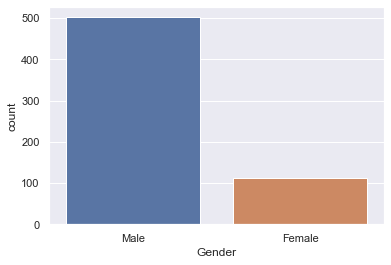

In [58]:
sns.countplot(data=data,x='Gender')

<AxesSubplot:xlabel='Married', ylabel='count'>

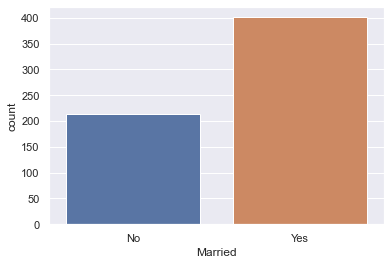

In [59]:
sns.countplot(data=data,x='Married')

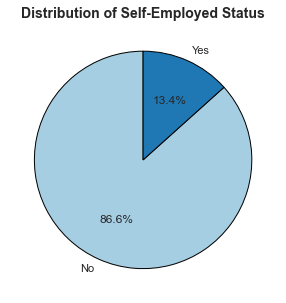

In [60]:
category_counts = category_counts = data['Self_Employed'].replace({0: 'Not Self Employed', 
  1: 'Self Employed'}).value_counts()
plt.figure(figsize=(5, 5))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',
 colors=sns.color_palette("Paired",
len(category_counts)), startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Self-Employed Status', fontsize=14, fontweight='bold')
plt.show()

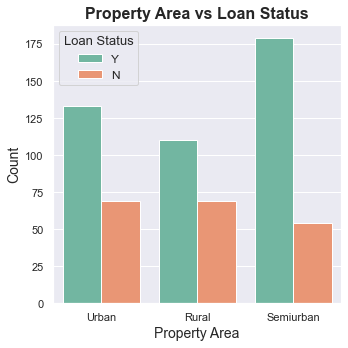

In [61]:
plt.figure(figsize=(5, 5))
ax = sns.countplot(data=data, x='Property_Area', hue='Loan_Status', palette='Set2')
ax.set_title('Property Area vs Loan Status', fontsize=16, fontweight='bold')
ax.set_xlabel('Property Area', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(title='Loan Status', title_fontsize='13', fontsize='12')
plt.tight_layout()
plt.show()

In [62]:
data.ApplicantIncome = np.sqrt(data.ApplicantIncome)
data.CoapplicantIncome = np.sqrt(data.CoapplicantIncome)
data.LoanAmount = np.sqrt(data.LoanAmount)

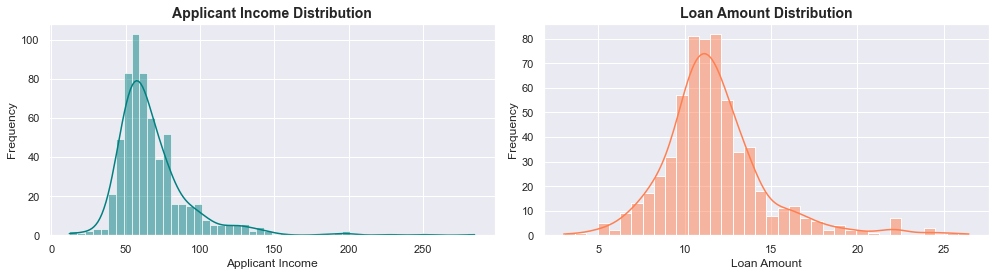

In [63]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=data, x="ApplicantIncome", kde=True, ax=axs[0], color='teal')  
axs[0].set_title('Applicant Income Distribution', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Applicant Income', fontsize=12)
axs[0].set_ylabel('Frequency', fontsize=12)
sns.histplot(data=data, x="LoanAmount", kde=True, ax=axs[1], color='coral') 
axs[1].set_title('Loan Amount Distribution', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Loan Amount', fontsize=12)
axs[1].set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [64]:
data.Loan_Status.replace('N',0,inplace=True)
data.Loan_Status.replace('Y',1,inplace=True)
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,76.478755,0.000000,12.100089,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,67.697858,38.832976,11.313708,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,54.772256,0.000000,8.124038,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,50.823223,48.559242,10.954451,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,77.459667,0.000000,11.874342,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,53.851648,0.000000,8.426150,360.0,1.0,Rural,1
610,LP002979,Male,Yes,3+,Graduate,No,64.078077,0.000000,6.324555,180.0,1.0,Rural,1
611,LP002983,Male,Yes,1,Graduate,No,89.844310,15.491933,15.905974,360.0,1.0,Urban,1
612,LP002984,Male,Yes,2,Graduate,No,87.080423,0.000000,13.674794,360.0,1.0,Urban,1


In [65]:
data['Education'] = LabelEncoder().fit_transform(data['Education'])
data['Dependents'] = LabelEncoder().fit_transform(data['Dependents'])
data['Self_Employed'] = LabelEncoder().fit_transform(data['Self_Employed'])
data['Gender'] = LabelEncoder().fit_transform(data['Gender'])
data['Married'] = LabelEncoder().fit_transform(data['Married'])
data['Property_Area'] = LabelEncoder().fit_transform(data['Property_Area'])
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,76.478755,0.000000,12.100089,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,67.697858,38.832976,11.313708,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,54.772256,0.000000,8.124038,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,50.823223,48.559242,10.954451,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,77.459667,0.000000,11.874342,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,0,0,53.851648,0.000000,8.426150,360.0,1.0,0,1
610,LP002979,1,1,3,0,0,64.078077,0.000000,6.324555,180.0,1.0,0,1
611,LP002983,1,1,1,0,0,89.844310,15.491933,15.905974,360.0,1.0,2,1
612,LP002984,1,1,2,0,0,87.080423,0.000000,13.674794,360.0,1.0,2,1


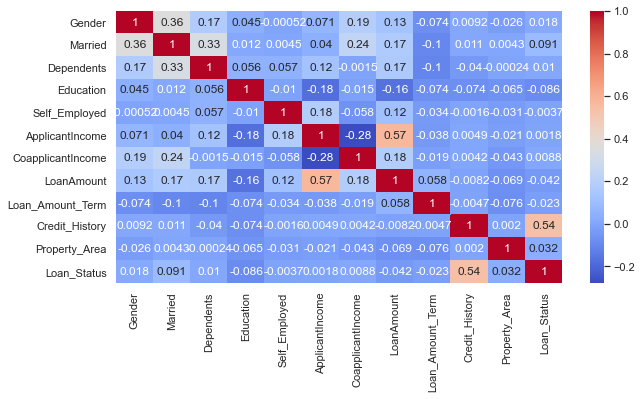

In [66]:
cor=data.corr()
plt.figure(figsize=(10,5))
sns.heatmap(cor,annot=True,cmap='coolwarm')
plt.show()

In [67]:
col=['Loan_ID','Gender','Married','CoapplicantIncome','Loan_Amount_Term','Property_Area']
data=data.drop(columns=col,axis=1)
data

,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Credit_History,Loan_Status
0,0,0,0,76.478755,12.100089,1.0,1
1,1,0,0,67.697858,11.313708,1.0,0
2,0,0,1,54.772256,8.124038,1.0,1
3,0,1,0,50.823223,10.954451,1.0,1
4,0,0,0,77.459667,11.874342,1.0,1
...,...,...,...,...,...,...,...
609,0,0,0,53.851648,8.426150,1.0,1
610,3,0,0,64.078077,6.324555,1.0,1
611,1,0,0,89.844310,15.905974,1.0,1
612,2,0,0,87.080423,13.674794,1.0,1


C:\Users\91720\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\91720\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)
<ipython-input-68-9edd62c57ce4>:17: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(X_train, y_train)
C:\Users\91720\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwar

--- Decision Tree ---
Accuracy: 69.11%
Precision (macro avg):  0.6603197674418604
Recall (macro avg):  0.6603197674418604
F1-Score (macro avg):  0.6603197674418604


--- KNN ---
Accuracy: 65.04%
Precision (macro avg):  0.5804347826086956
Recall (macro avg):  0.5215116279069767
F1-Score (macro avg):  0.4681749622926093


--- Logistic Regression ---
Accuracy: 78.86%
Precision (macro avg):  0.853491902834008
Recall (macro avg):  0.7030523255813954
F1-Score (macro avg):  0.7196704067321178


--- Random Forest ---
Accuracy: 74.80%
Precision (macro avg):  0.7416732751784298
Recall (macro avg):  0.6771802325581395
F1-Score (macro avg):  0.6877916973716531


--- SVM ---
Accuracy: 65.04%
Precision (macro avg):  0.3252032520325203
Recall (macro avg):  0.5
F1-Score (macro avg):  0.39408866995073893




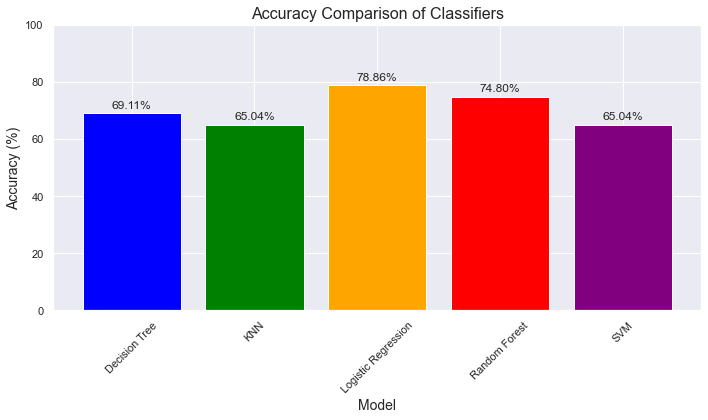

In [68]:
x=data[['Dependents','Education','Self_Employed','ApplicantIncome','LoanAmount','Credit_History']]
y=data[['Loan_Status']]
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state =42)
# Define the models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(random_state=42)
}
accuracy_results = {}
classification_reports = {}

# Train each model
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[model_name] = accuracy * 100  # Convert to percentage
    
    # Classification Report (Precision, Recall, F1 Score)
    report = classification_report(y_test, y_pred, output_dict=True)
    classification_reports[model_name] = report
    
for model_name, report in classification_reports.items():
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy_results[model_name]:.2f}%")
    print("Precision (macro avg): ", report['macro avg']['precision'])
    print("Recall (macro avg): ", report['macro avg']['recall'])
    print("F1-Score (macro avg): ", report['macro avg']['f1-score'])
    print("\n")

# Plotting the accuracy comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(accuracy_results.keys(), accuracy_results.values(), color=['blue', 'green', 'orange', 'red', 'purple'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=12)
plt.title('Accuracy Comparison of Classifiers', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(0, 100)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()
